## 1. Introduction

This notebook performs K-Means clustering on the linguistic variables extracted in Part 1 and summarized through PCA in Part 2. The objective is to identify participant profiles based on their linguistic behavior.

In [110]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 2. Data Loading

In [111]:
### Read the data
# Dataset generated in Part 2 (PCA analysis)
path =r'data\PersuasionPART3_pca.csv'
df = pd.read_csv(path,sep=',', encoding='utf-8')

In [112]:
df.head(3)

,Est,Edad,Impuso,Extro,Cant_arg,connectors_total,politeness_total,rud_total,powerless_total,Impuso_n,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6
0,1,23,0,31,7,27,6,14,0,1,-0.787304,-0.564611,0.957000,0.303207,-0.171353,-0.095240
1,2,35,1,35,10,76,12,39,12,2,2.413580,1.337830,-0.857722,0.602793,0.002395,0.113867
2,3,19,0,28,7,39,6,18,4,1,-0.160588,-0.270873,-0.051872,0.053729,-0.070910,-0.104453


## 3. Data Standardization

In [113]:
# Standarization
# Standardization is essential because K-Means relies on Euclidean distance
df_standardized = df.copy()
cols_to_norm = ['Extro','Cant_arg','connectors_total','politeness_total','rud_total','powerless_total']
df_standardized[cols_to_norm] = StandardScaler().fit_transform(df_standardized[cols_to_norm])

## 4. Determining the Number of Clusters

In [114]:
xy = df_standardized[['Comp.1', 'Comp.2']]
z = df_standardized.loc[:,'Extro':'powerless_total']

In [115]:
xygraf= xy.to_numpy()
ztrain =z.to_numpy()

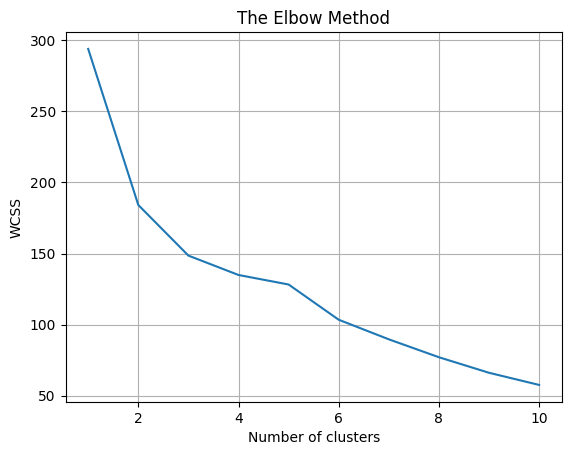

In [116]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(ztrain)
    wcss.append(kmeans.inertia_)

# Grafica de la suma de las distancias
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

## 5. K-Means Clustering

In [117]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(ztrain)

In [118]:
df_standardized['pred_k'] = y_kmeans
df['pred_k'] = y_kmeans

In [119]:
df.head(4)

,Est,Edad,Impuso,Extro,Cant_arg,connectors_total,politeness_total,rud_total,powerless_total,Impuso_n,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6,pred_k
0,1,23,0,31,7,27,6,14,0,1,-0.787304,-0.564611,0.957000,0.303207,-0.171353,-0.095240,0
1,2,35,1,35,10,76,12,39,12,2,2.413580,1.337830,-0.857722,0.602793,0.002395,0.113867,1
2,3,19,0,28,7,39,6,18,4,1,-0.160588,-0.270873,-0.051872,0.053729,-0.070910,-0.104453,0
3,4,19,1,24,11,55,2,14,4,2,-0.103583,-0.677571,-0.157129,-0.946167,0.494386,-0.497104,3


## 6. Cluster Visualization

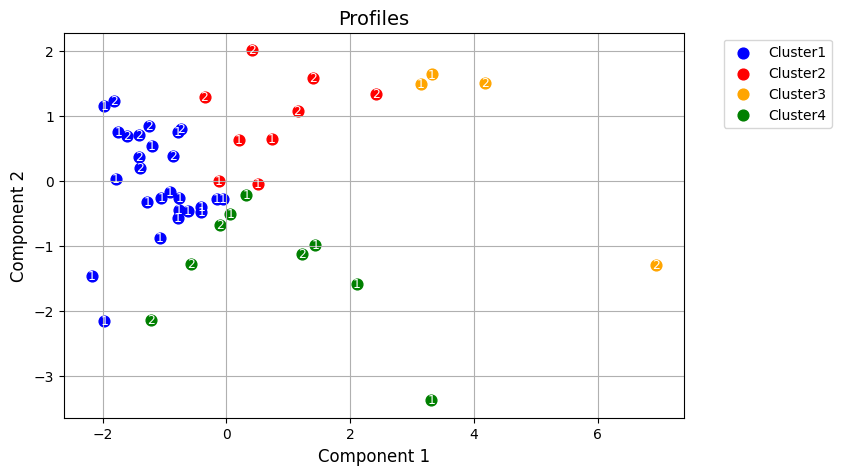

In [120]:
plt.figure(figsize=(8, 5), facecolor='white', frameon=True)  # Asegúrate de que 'frameon' sea True
plt.scatter(xygraf[y_kmeans == 0, 0], xygraf[y_kmeans == 0, 1], s=60, c='blue', label='Cluster1')
plt.scatter(xygraf[y_kmeans == 1, 0], xygraf[y_kmeans == 1, 1], s=60, c='red', label='Cluster2')
plt.scatter(xygraf[y_kmeans == 2, 0], xygraf[y_kmeans == 2, 1], s=60, c='orange', label='Cluster3')
plt.scatter(xygraf[y_kmeans == 3, 0], xygraf[y_kmeans == 3, 1], s=60, c='green', label='Cluster4')


for i in range(len(xygraf)):
    plt.text(xygraf[i, 0], xygraf[i, 1], str(df["Impuso_n"][i]), fontsize=9, ha='center', va='center', color='white')

handles, labels = plt.gca().get_legend_handles_labels()

order = [0, 1, 2, 3]
handles = [handles[i] for i in order]
labels = [labels[i] for i in order]

# Mostrar la leyenda en el orden especificado
plt.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.25, 1))

plt.title('Profiles', fontsize=14)
plt.xlabel('Component 1', fontsize=12)
plt.ylabel('Component 2', fontsize=12)
plt.grid(True)


# Mostrar el gráfico
plt.show()

## 7. Cluster Description

In [121]:
cluster_means = df.groupby(['pred_k']).mean()
cluster_means

,Est,Edad,Impuso,Extro,Cant_arg,connectors_total,politeness_total,rud_total,powerless_total,Impuso_n,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6
pred_k,,,,,,,,,,,,,,,,
0,26.259259,20.296296,0.296296,31.259259,4.740741,20.074074,3.740741,10.666667,2.666667,1.296296,-1.128272,0.000948,0.302497,0.044634,0.000013,0.032383
1,23.333333,22.333333,0.555556,32.666667,6.000000,52.111111,8.000000,22.555556,9.111111,1.555556,0.704271,0.944388,-0.749226,0.360742,0.020244,-0.064517
2,29.250000,20.750000,0.500000,35.750000,19.250000,126.500000,11.750000,65.500000,9.750000,1.500000,4.390668,0.835169,0.341030,-0.492004,-0.146697,-0.026224
3,21.000000,20.111111,0.444444,20.333333,12.222222,50.777778,7.111111,27.222222,3.888889,1.444444,0.729138,-1.318417,-0.309834,-0.275974,0.044915,-0.020977


In [122]:
df.head(3)

,Est,Edad,Impuso,Extro,Cant_arg,connectors_total,politeness_total,rud_total,powerless_total,Impuso_n,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6,pred_k
0,1,23,0,31,7,27,6,14,0,1,-0.787304,-0.564611,0.957000,0.303207,-0.171353,-0.095240,0
1,2,35,1,35,10,76,12,39,12,2,2.413580,1.337830,-0.857722,0.602793,0.002395,0.113867,1
2,3,19,0,28,7,39,6,18,4,1,-0.160588,-0.270873,-0.051872,0.053729,-0.070910,-0.104453,0


In [123]:
dfsum = df[['pred_k', 'Impuso']]
dfsum = dfsum.groupby('pred_k').count()
dfsum

,Impuso
pred_k,
0,27
1,9
2,4
3,9


In [124]:
dfsum = pd.crosstab(df['pred_k'], df['Impuso_n'])

In [125]:
dfsum

Impuso_n,1,2
pred_k,,
0,19,8
1,4,5
2,2,2
3,5,4


In [126]:
cluster_means = df_standardized.groupby(['pred_k']).mean()
cluster_means

,Est,Edad,Impuso,Extro,Cant_arg,connectors_total,politeness_total,rud_total,powerless_total,Impuso_n,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6
pred_k,,,,,,,,,,,,,,,,
0,26.259259,20.296296,0.296296,0.181387,-0.423526,-0.609189,-0.438174,-0.536409,-0.551749,1.296296,-1.128272,0.000948,0.302497,0.044634,0.000013,0.032383
1,23.333333,22.333333,0.555556,0.366147,-0.232360,0.356424,0.469921,0.120999,1.238287,1.555556,0.704271,0.944388,-0.749226,0.360742,0.020244,-0.064517
2,29.250000,20.750000,0.500000,0.770919,1.779101,2.598543,1.269439,2.495655,1.415747,1.500000,4.390668,0.835169,0.341030,-0.492004,-0.146697,-0.026224
3,21.000000,20.111111,0.444444,-1.252938,0.712225,0.316236,0.280405,0.379047,-0.212260,1.444444,0.729138,-1.318417,-0.309834,-0.275974,0.044915,-0.020977


In [127]:
cluster_means.head(5)

,Est,Edad,Impuso,Extro,Cant_arg,connectors_total,politeness_total,rud_total,powerless_total,Impuso_n,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6
pred_k,,,,,,,,,,,,,,,,
0,26.259259,20.296296,0.296296,0.181387,-0.423526,-0.609189,-0.438174,-0.536409,-0.551749,1.296296,-1.128272,0.000948,0.302497,0.044634,0.000013,0.032383
1,23.333333,22.333333,0.555556,0.366147,-0.232360,0.356424,0.469921,0.120999,1.238287,1.555556,0.704271,0.944388,-0.749226,0.360742,0.020244,-0.064517
2,29.250000,20.750000,0.500000,0.770919,1.779101,2.598543,1.269439,2.495655,1.415747,1.500000,4.390668,0.835169,0.341030,-0.492004,-0.146697,-0.026224
3,21.000000,20.111111,0.444444,-1.252938,0.712225,0.316236,0.280405,0.379047,-0.212260,1.444444,0.729138,-1.318417,-0.309834,-0.275974,0.044915,-0.020977


In [128]:
x = cluster_means.iloc[:, 3:9]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[ 0.216198  , -1.0082569 , -1.07933742, -1.3715114 , -1.0133758 ,
        -1.18386777],
       [ 0.45827606, -0.78982132, -0.26171126,  0.12261588, -0.43469022,
         0.88511395],
       [ 0.98861813,  1.50857076,  1.63678832,  1.43809751,  1.65560864,
         1.09022851],
       [-1.6630922 ,  0.28950746, -0.29573964, -0.18920199, -0.20754261,
        -0.79147469]])

In [129]:
persuasion_rate = (dfsum[2] / (dfsum[1] + dfsum[2])).round(2)
persuasion_rate

pred_k
0    0.30
1    0.56
2    0.50
3    0.44
dtype: float64

## 8. Radar Plot Profiles

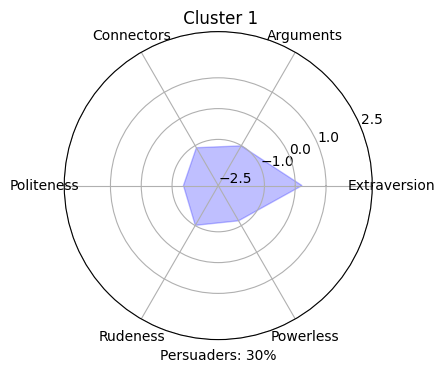

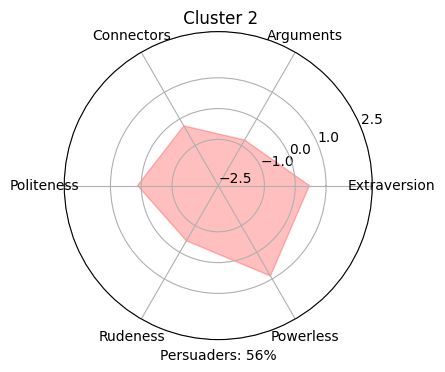

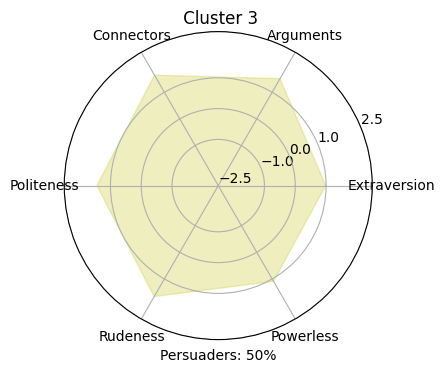

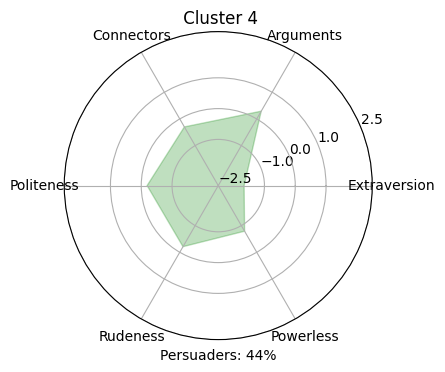

In [130]:
# Standardized cluster means rounded for radar plot visualization

Cluster_1 = np.round(x_scaled[0], 2).tolist()
Cluster_2 = np.round(x_scaled[1], 2).tolist()
Cluster_3 = np.round(x_scaled[2], 2).tolist()
Cluster_4 = np.round(x_scaled[3], 2).tolist()
persuasion_rate = (dfsum[2] / (dfsum[1] + dfsum[2])).round(2)
variables = ['Extraversion', 'Arguments',	'Connectors', 'Politeness', 'Rudeness', 'Powerless']

num_variables = len(variables)

angles = np.linspace(0, 2 * np.pi, num_variables, endpoint=False).tolist()


Cluster_1 += Cluster_1[:1]
Cluster_2 += Cluster_2[:1]
Cluster_3 += Cluster_3[:1]
Cluster_4 += Cluster_4[:1]
angles += angles[:1]


colores = ['b', 'r', 'y','g']
casos = [Cluster_1, Cluster_2, Cluster_3, Cluster_4]
etiquetas = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

legend_persuade = [f"Persuaders: {int(i*100)}%"for i in persuasion_rate]

valores_personalizados = [-2.5, -1, 0, 1, 2.5]


for i, case in enumerate(casos):
    plt.figure(figsize=(4, 4))
    ax = plt.subplot(111, polar=True)

    ax.fill(angles, case, color=colores[i], alpha=0.25, label=etiquetas[i])

    plt.xticks(angles[:-1], variables)
    ax.set_yticks(valores_personalizados)

    plt.title(f' {etiquetas[i]}')
    
    plt.text(0.5, -0.05, legend_persuade[i], transform=ax.transAxes, ha='center', va='center')
    plt.show()

## 9. Dataset Export

In [131]:
# Save the data locally if necessary
df_standardized.to_csv(r'data\PersuasionPART4_std.csv', sep=',')